# Sample complexity and aspect ratio

Study how the proportional aspect ratio interacts with supervision and pseudo-label feedback.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

import numpy as np
import torch
from matplotlib import pyplot as plt
from scipy.special import logit

torch.set_default_dtype(torch.float64)
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks.experiment_helpers import (
    as_numpy,
    finite_state_observables,
    finite_update_observables,
    make_algorithm_config,
    trajectory_diagnostics,
    plot_macroscopic_evolution,
    make_parameter_base_sampler,
    mean_and_std,
    run_experiment,
    run_oracle_selected_label_counterfactual,
    state_evolution_state_observables,
    state_evolution_update_observables,
)
from src.asymptotics import MacroscopicStateEvolution
from src.config import DataConfig
from src.environment import FourCellSampleTypeLaw, state_evolution_sample_base_sampler

from src.performance import bayes_parameters, population_error


This notebook first sweeps $\delta=n/d$ at fixed supervision.  The optional two-dimensional computation then maps
$$
(\rho,\delta)\mapsto \mathcal E_{\rm ST}^T-\mathcal E_{\rm sup}^T.
$$
All finite/SE comparisons validate the realized $n/d$ against $\bar\delta$ explicitly.

In [3]:
SEED = 5100
T, D = 50, 2000
K_W, K_G = 3_500, 4_200
DELTAS = np.array([0.25, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0, 32.0])
RHO, SIGMA, P = 0.1, 1.0, 0.2

records = []
for index, delta in enumerate(DELTAS):
    cfg_st = make_algorithm_config(T=T, eta=0.1, penalty=0.1, pi=5.0, kappa=logit(0.8))
    cfg_sup = make_algorithm_config(T=T, eta=0.1, penalty=0.1, pi=0.0, kappa=logit(0.8))
    common = dict(d=D, delta=float(delta), n_test=2_000, label_prior=P, rho=RHO, sigma=SIGMA, signal_std=1.0, K_w=K_W, K_g=K_G)
    st = run_experiment(name="self-training", algo_cfg=cfg_st, seed=SEED + index, **common)
    sup = run_experiment(name="supervised", algo_cfg=cfg_sup, seed=SEED + index, **common)
    st_state, st_update = state_evolution_state_observables(st), state_evolution_update_observables(st)
    records.append((delta, st_state["error"][-1], sup_error := state_evolution_state_observables(sup)["error"][-1], st_state["m"][-1], st_update["omega"][-1], st_update["accuracy"][-1]))
records = np.asarray(records)

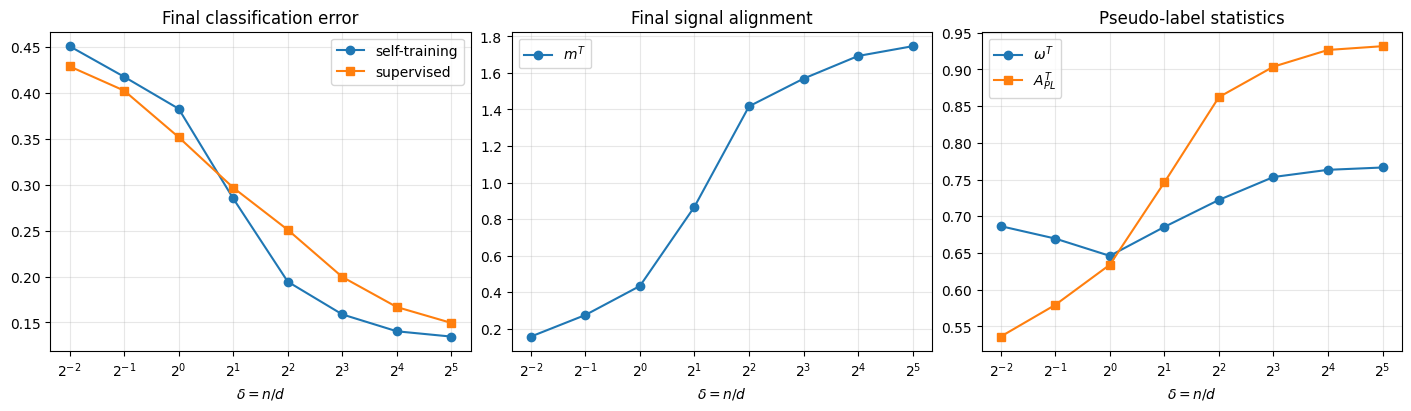

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
axes[0].plot(records[:, 0], records[:, 1], marker="o", label="self-training")
axes[0].plot(records[:, 0], records[:, 2], marker="s", label="supervised")
axes[1].plot(records[:, 0], records[:, 3], marker="o", label=r"$m^T$")
axes[2].plot(records[:, 0], records[:, 4], marker="o", label=r"$\omega^T$")
axes[2].plot(records[:, 0], records[:, 5], marker="s", label=r"$A_{PL}^T$")
for ax in axes:
    ax.set_xscale("log", base=2); ax.set_xlabel(r"$\delta=n/d$"); ax.grid(alpha=0.3); ax.legend()
axes[0].set_title("Final classification error"); axes[1].set_title("Final signal alignment"); axes[2].set_title("Pseudo-label statistics")
plt.show()

In [5]:
T, D = 50, 2000
RHOS = np.array([0.01, 0.02, 0.05, 0.1])

gain = np.empty((len(RHOS), len(DELTAS)))
for i, rho in enumerate(RHOS):
    for j, delta in enumerate(DELTAS):
        common = dict(d=D, delta=float(delta), n_test=2_000, label_prior=0.2, rho=float(rho), sigma=SIGMA, signal_std=1.0, K_w=K_W, K_g=K_G)
        st = run_experiment(name="ST", algo_cfg=make_algorithm_config(T=T, eta=0.1, penalty=0.1, pi=5.0, kappa=logit(0.8)), seed=SEED + 100*i+j, **common)
        sup = run_experiment(name="SUP", algo_cfg=make_algorithm_config(T=T, eta=0.1, penalty=0.1, pi=0.0, kappa=logit(0.8)), seed=SEED + 100*i+j, **common)
        gain[i, j] = state_evolution_state_observables(st)["error"][-1] - state_evolution_state_observables(sup)["error"][-1]

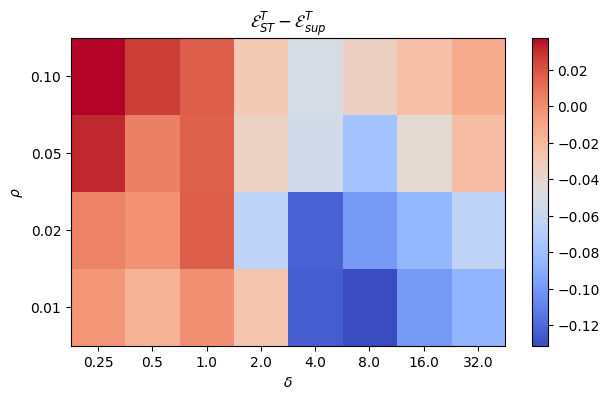

In [6]:
rounded_rhos = [f"{r:.2f}" for r in RHOS]

plt.figure(figsize=(7, 4))
plt.imshow(gain, aspect="auto", origin="lower", cmap="coolwarm")
plt.xticks(ticks=np.arange(len(DELTAS)), labels=DELTAS)
plt.yticks(ticks=np.arange(len(RHOS)), labels=rounded_rhos)
plt.xlabel(r"$\delta$")
plt.ylabel(r"$\rho$")
plt.title(r"$\mathcal{E}_{ST}^T-\mathcal{E}_{sup}^T$")
plt.colorbar()
plt.show()

## Comparison: Labeled-Unlabeled-Oracle-Bayes ($\rho = 0.01, \delta = 8.0$)

In [7]:
# Matched-data trajectory comparison
#
# The oracle uses the same total sample size n as the self-training arm, with
# every observation revealed as labelled (rho=1).  Thus it is a labelled-data
# upper benchmark, not the selected-label counterfactual used elsewhere.
COMPARISON_SIGMA, COMPARISON_P, COMPARISON_T = SIGMA, P, 400
COMPARISON_RHO, COMPARISON_DELTA = 0.01, 8.0
comparison_common = dict(
    d=D, delta=COMPARISON_DELTA, n_test=2_000, label_prior=0.2,
    sigma=COMPARISON_SIGMA, signal_std=1.0, K_w=K_W, K_g=K_G,
)
comparison_cfg = dict(T=COMPARISON_T, eta=0.1, penalty=0.1, kappa=logit(0.8))
comparison_seed = SEED + 10_000
comparison_runs = {
    "labelled only ($\pi=0$)": run_experiment(
        name="labelled only", rho=COMPARISON_RHO,
        algo_cfg=make_algorithm_config(pi=0.0, **comparison_cfg),
        seed=comparison_seed, **comparison_common,
    ),
    "unlabelled ($\pi=2$)": run_experiment(
        name="unlabelled", rho=COMPARISON_RHO,
        algo_cfg=make_algorithm_config(pi=2.0, **comparison_cfg),
        seed=comparison_seed, **comparison_common,
    ),
    "oracle (all $n$ labelled)": run_experiment(
        name="oracle", rho=1.0,
        algo_cfg=make_algorithm_config(pi=0.0, **comparison_cfg),
        seed=comparison_seed, **comparison_common,
    ),
}

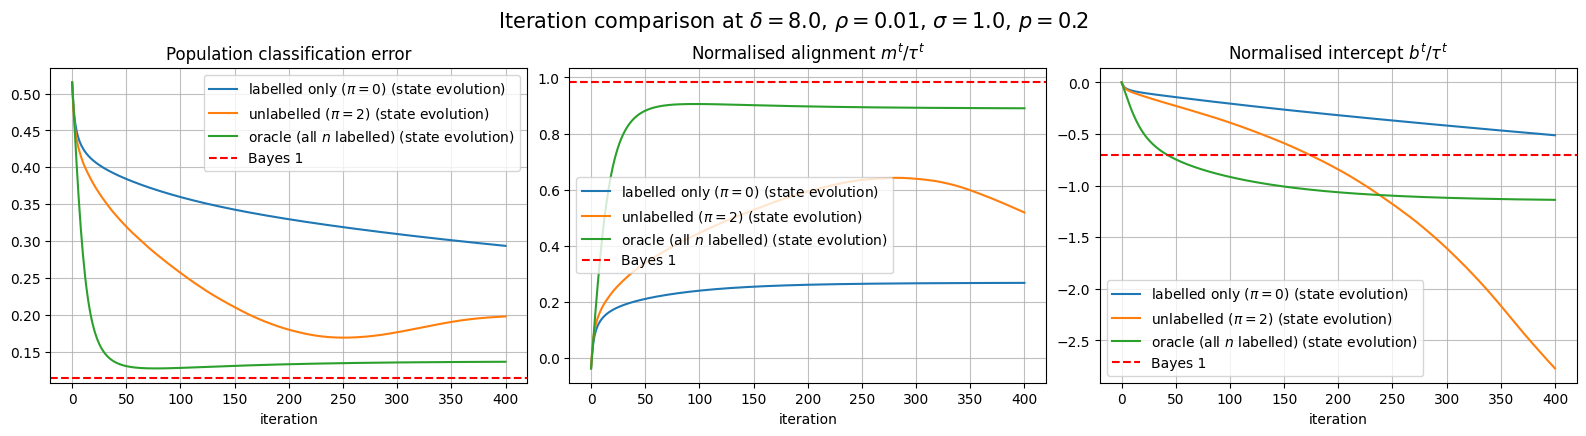

(<Figure size 1575x425 with 3 Axes>,
 array([[<Axes: title={'center': 'Population classification error'}, xlabel='iteration'>,
         <Axes: title={'center': 'Normalised alignment $m^t/\\tau^t$'}, xlabel='iteration'>,
         <Axes: title={'center': 'Normalised intercept $b^t/\\tau^t$'}, xlabel='iteration'>]],
       dtype=object))

In [8]:
plot_macroscopic_evolution(
    comparison_runs,
    quantities=("error", "normalized_alignment", "normalized_bias"),
    sources=("state_evolution",),
    include_bayes=True,
    title=(
        rf"Iteration comparison at $\delta={COMPARISON_DELTA}$, $\rho={COMPARISON_RHO}$, "
        rf"$\sigma={COMPARISON_SIGMA}$, $p={COMPARISON_P}$"
    ),
)

We see that with these parameters, the pseudo-labeling the final classification performance, and exhibits a U-shaped error curve, before converging to the majority class classifier because of the diverging bias, which has an error of 0.2.

## Comparison: Labeled-Unlabeled-Oracle-Bayes ($\rho = 0.1, \delta = 0.25$)

In [9]:
# Matched-data trajectory comparison
#
# The oracle uses the same total sample size n as the self-training arm, with
# every observation revealed as labelled (rho=1).  Thus it is a labelled-data
# upper benchmark, not the selected-label counterfactual used elsewhere.
COMPARISON_SIGMA, COMPARISON_P, COMPARISON_T = SIGMA, P, 400
COMPARISON_RHO, COMPARISON_DELTA = 0.1, 0.25
comparison_common = dict(
    d=D, delta=COMPARISON_DELTA, n_test=2_000, label_prior=0.2,
    sigma=COMPARISON_SIGMA, signal_std=1.0, K_w=K_W, K_g=K_G,
)
comparison_cfg = dict(T=COMPARISON_T, eta=0.1, penalty=0.1, kappa=logit(0.8))
comparison_seed = SEED + 10_000
comparison_runs = {
    "labelled only ($\pi=0$)": run_experiment(
        name="labelled only", rho=COMPARISON_RHO,
        algo_cfg=make_algorithm_config(pi=0.0, **comparison_cfg),
        seed=comparison_seed, **comparison_common,
    ),
    "unlabelled ($\pi=2$)": run_experiment(
        name="unlabelled", rho=COMPARISON_RHO,
        algo_cfg=make_algorithm_config(pi=2.0, **comparison_cfg),
        seed=comparison_seed, **comparison_common,
    ),
    "oracle (all $n$ labelled)": run_experiment(
        name="oracle", rho=1.0,
        algo_cfg=make_algorithm_config(pi=0.0, **comparison_cfg),
        seed=comparison_seed, **comparison_common,
    ),
}

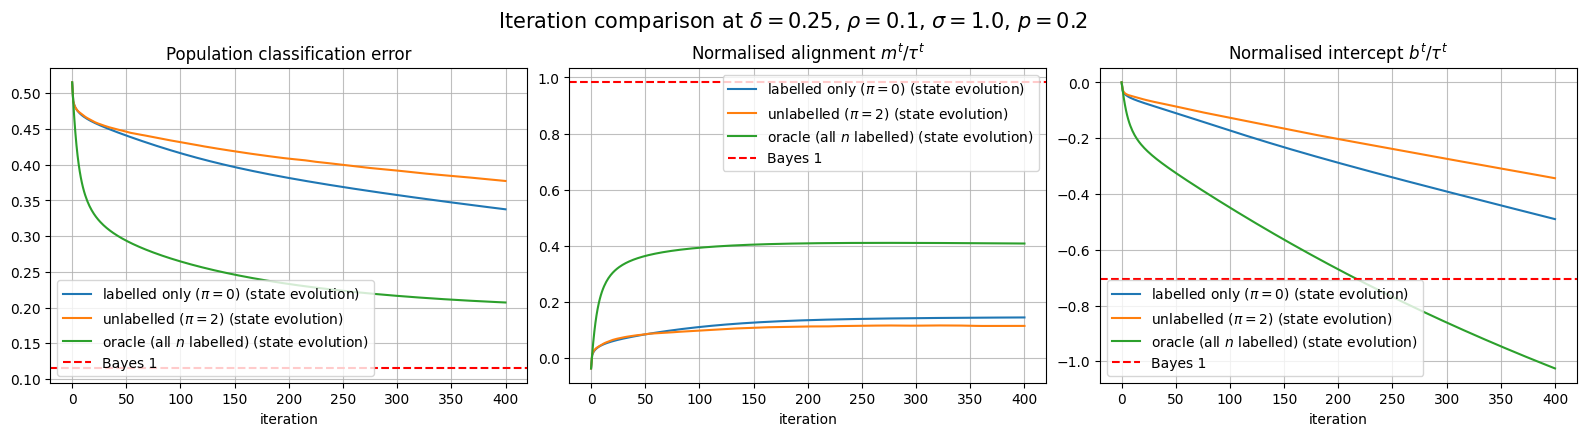

(<Figure size 1575x425 with 3 Axes>,
 array([[<Axes: title={'center': 'Population classification error'}, xlabel='iteration'>,
         <Axes: title={'center': 'Normalised alignment $m^t/\\tau^t$'}, xlabel='iteration'>,
         <Axes: title={'center': 'Normalised intercept $b^t/\\tau^t$'}, xlabel='iteration'>]],
       dtype=object))

In [10]:
plot_macroscopic_evolution(
    comparison_runs,
    quantities=("error", "normalized_alignment", "normalized_bias"),
    sources=("state_evolution",),
    include_bayes=True,
    title=(
        rf"Iteration comparison at $\delta={COMPARISON_DELTA}$, $\rho={COMPARISON_RHO}$, "
        rf"$\sigma={COMPARISON_SIGMA}$, $p={COMPARISON_P}$"
    ),
)

## Outcome classification and Bayes excess

The diagnostic below reports Bayes excess and a transparent intercept-dominance collapse flag for each sampled trajectory.

In [11]:
RUN_DELTA_OUTCOME_DIAGNOSTICS = True
if RUN_DELTA_OUTCOME_DIAGNOSTICS:
    outcome_rows = []
    for delta in DELTAS:
        st = run_experiment(name=rf"ST, delta={delta}", d=D, delta=float(delta), n_test=2_000, label_prior=0.2, rho=RHO, sigma=SIGMA, signal_std=1.0, algo_cfg=make_algorithm_config(T=T, eta=0.1, penalty=0.1, pi=5.0, kappa=logit(0.8)), seed=SEED + int(100 * delta), K_w=K_W, K_g=K_G)
        diagnostic = trajectory_diagnostics(st)
        b_star, m_star, tau_star = bayes_parameters(st.signal_scale, SIGMA, 0.2)
        bayes_error = population_error(b_star, m_star, tau_star, SIGMA, 0.2)
        outcome_rows.append((delta, diagnostic["terminal_error"] - bayes_error, diagnostic["minimum_error"] - bayes_error, diagnostic["collapsed"]))
    for row in outcome_rows: print(dict(zip(("delta", "terminal_bayes_excess", "best_bayes_excess", "collapsed"), row)))

{'delta': np.float64(0.25), 'terminal_bayes_excess': np.float64(0.34624092374952786), 'best_bayes_excess': np.float64(0.34624092374952786), 'collapsed': False}
{'delta': np.float64(0.5), 'terminal_bayes_excess': np.float64(0.30680881959216066), 'best_bayes_excess': np.float64(0.30680881959216066), 'collapsed': False}
{'delta': np.float64(1.0), 'terminal_bayes_excess': np.float64(0.27479327579702933), 'best_bayes_excess': np.float64(0.27479327579702933), 'collapsed': False}
{'delta': np.float64(2.0), 'terminal_bayes_excess': np.float64(0.18092277682577743), 'best_bayes_excess': np.float64(0.18092277682577743), 'collapsed': False}
{'delta': np.float64(4.0), 'terminal_bayes_excess': np.float64(0.11113171210362295), 'best_bayes_excess': np.float64(0.11113171210362295), 'collapsed': False}
{'delta': np.float64(8.0), 'terminal_bayes_excess': np.float64(0.06398733433662107), 'best_bayes_excess': np.float64(0.06398733433662107), 'collapsed': False}
{'delta': np.float64(16.0), 'terminal_bayes_e